In [11]:
import pandas as pd

# Cargar cada archivo en un DataFrame
dim_category = pd.read_csv('DIM_CATEGORY.csv')  
dim_product  = pd.read_excel('DIM_PRODUCT.xlsx')
dim_segment  = pd.read_excel('DIM_SEGMENT.xlsx')
dim_calendar = pd.read_excel('DIM_CALENDAR.xlsx')
fact_sales   = pd.read_csv('FACT_SALES.csv')


In [12]:
!dir

 El volumen de la unidad C no tiene etiqueta.
 El n£mero de serie del volumen es: A872-66B6

 Directorio de C:\Users\SURFACE

29/01/2026  09:50 a. m.    <DIR>          .
16/03/2025  09:39 p. m.    <DIR>          ..
30/06/2025  06:23 p. m.    <DIR>          .anaconda
08/11/2025  03:52 p. m.    <DIR>          .conda
25/06/2025  09:56 p. m.                25 .condarc
25/06/2025  09:55 p. m.    <DIR>          .continuum
27/01/2026  09:49 a. m.    <DIR>          .ipynb_checkpoints
30/06/2025  06:25 p. m.    <DIR>          .ipython
02/01/2026  10:22 a. m.    <DIR>          .jupyter
12/11/2025  12:32 p. m.    <DIR>          .matplotlib
07/10/2024  06:28 p. m.    <DIR>          3D Objects
25/06/2025  10:00 p. m.    <DIR>          anaconda3
30/06/2025  06:22 p. m.    <DIR>          anaconda_projects
05/01/2026  10:16 a. m.            32,773 co2-mm-mlo_csv.csv
17/03/2025  09:27 p. m.    <DIR>          Contacts
20/01/2026  12:08 p. m.           579,522 Creacion de graficos complejos.ipynb
20/01/2

In [3]:
# Dicccionario con nombre y DataFrame
dataframes = {
    "DIM_CATEGORY": dim_category,
    "DIM_PRODUCT": dim_product,
    "DIM_SEGMENT": dim_segment,
    "DIM_CALENDAR": dim_calendar,
    "FACT_SALES": fact_sales
}
# Recorrer los DataFrame y mostrar información, tambien se puede hacer con print pero mejor un for para condensar.
for name, df in dataframes.items():
    print(f"=== {name} ===")
    print(df.head(), "\n") # Primeras filas
    print(df.info(), "\n") # Informacion general
    print(df.describe(include='all'), "\n")  # Estadistica

=== DIM_CATEGORY ===
   ID_CATEGORY                        CATEGORY
0            1  FABRIC TREATMENT and SANIT\r\n
1            2                       AIR CARE 
2            3                    LAVAVAJILLAS
3            4                MEGA SUPERFICIES
4            5             LAVATORY CARE & BRC 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID_CATEGORY  5 non-null      int64 
 1   CATEGORY     5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes
None 

        ID_CATEGORY                        CATEGORY
count      5.000000                               5
unique          NaN                               5
top             NaN  FABRIC TREATMENT and SANIT\r\n
freq            NaN                               1
mean       3.000000                             NaN
std        1.581139                             NaN
min  

In [13]:
# Limpieza de los datos
for name, df in dataframes.items():
    print(f"=== Limpieza de {name} ===")
    
    # Corregir posibles inconsistencias en nombres de columnas
    df.columns = df.columns.str.strip() #.strio elimina espacios en blanco
    
    # Manejo de valores nulos
    print("Valores nulos por columna:")
    print(df.isnull().sum())
    
    # Ejemplo de acción: eliminar filas con nulos
    df.dropna(inplace=True)
    
    # Identificar y eliminar duplicados... aqui decidi eliminarlos pero lo correcto seria preguntar y ver en el contexto
    #si tiene sentido o si caen en la descripcion de datos repetidos, por el momento, se eliminan para el proyecto
    duplicados = df.duplicated().sum()
    print(f"Duplicados encontrados: {duplicados}")
    df.drop_duplicates(inplace=True)
    
    print(f"Dimensiones finales: {df.shape}\n")

NameError: name 'dataframes' is not defined

In [10]:
#Determina qué variables son más relevantes para responder a las preguntas de negocio

#Las variables mas importantes son el total units sales, el total value sales y el total unit avererage weekly sales
#porque son las variables que dictan cuanto se vende en el negocio. Las demas variables pueden ser de apoyo por ejemplo
#quien manufactura, o las fechas ya que pueden ser un indicador de quien vende mas y cuales son las fechas fuertes.

#VISUALIZACION DE DATOS
print(fact_sales.columns)
print(dim_product.columns)
print(dim_category.columns)
print(dim_segment.columns)
print(dim_calendar.columns)

Index(['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
       'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION'],
      dtype='object')
Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3'],
      dtype='object')
Index(['ID_CATEGORY', 'CATEGORY'], dtype='object')
Index(['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT', 'SEGMENT'], dtype='object')
Index(['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE'], dtype='object')


# Assistant
The error occurs because the code is trying to merge DataFrames using a column name that doesn't exist or is named differently in one of the DataFrames.

The error specifically points to a KeyError with 'item', which suggests that the column "item" doesn't exist in the `dim_product` DataFrame when you're trying to merge it with `fact_sales`.

Would you like me to provide the corrected code?

In [11]:
sales_products = fact_sales.merge(dim_product, left_on="ITEM_CODE", right_on="ITEM")

In [12]:
sales_products = sales_products.merge(dim_category, left_on="CATEGORY", right_on="ID_CATEGORY")

In [15]:
sales_products = sales_products.merge(dim_calendar, on="WEEK", how="left")

) missing from font(s) DejaVu Sans.-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


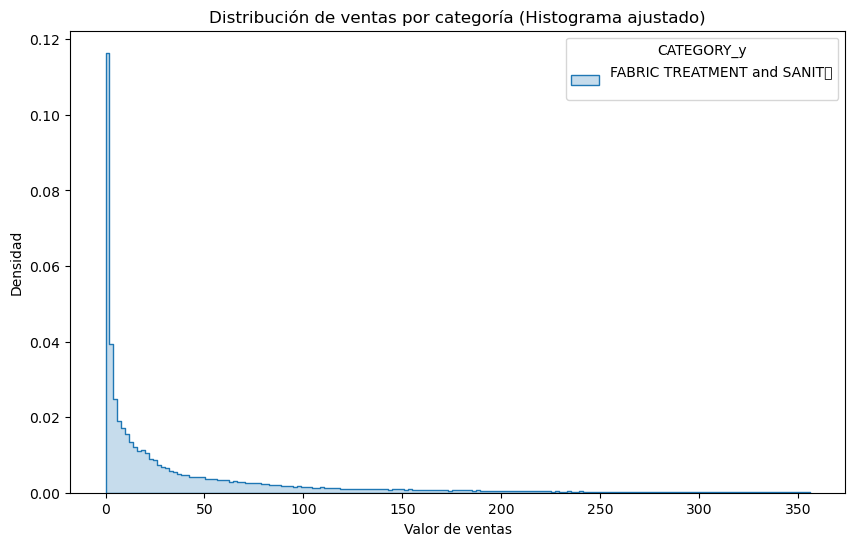

C:\Users\SURFACE\AppData\Local\Temp\ipykernel_2416\965053417.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
) missing from font(s) DejaVu Sans.-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


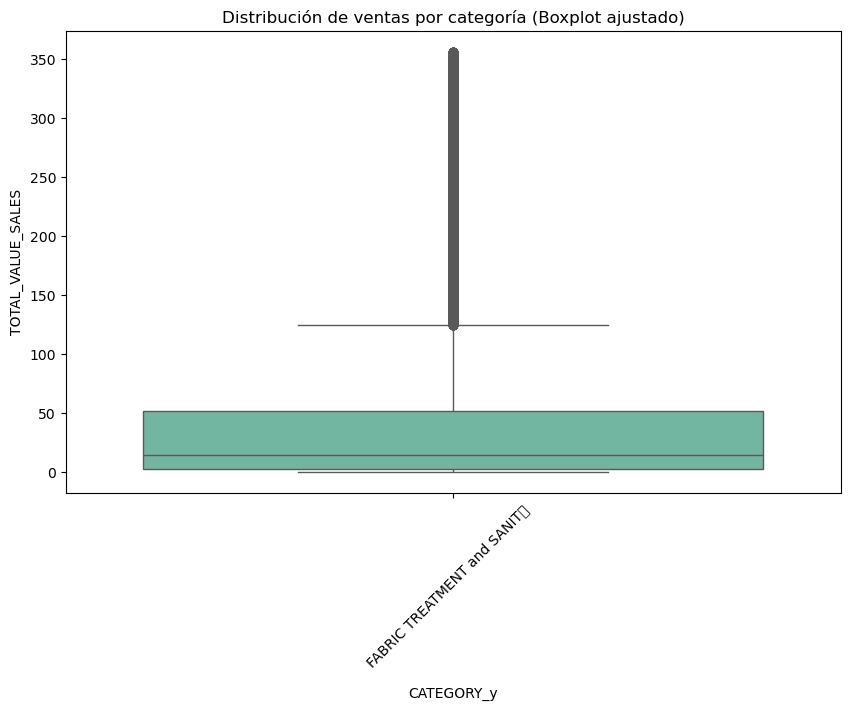

In [17]:
# Merge FACT_SALES con DIM_PRODUCT
sales_products = fact_sales.merge(dim_product, left_on="ITEM_CODE", right_on="ITEM")

# Merge con DIM_CATEGORY
sales_products = sales_products.merge(dim_category, left_on="CATEGORY", right_on="ID_CATEGORY")

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar outliers: eliminar valores por encima del percentil 95, ya que si le doy la instruccion tal cual
#los valores se hacen muy extremos
filtered = sales_products[sales_products["TOTAL_VALUE_SALES"] < sales_products["TOTAL_VALUE_SALES"].quantile(0.95)]

# Verificar nombre de columna de categoría
category_col = "CATEGORY_y" if "CATEGORY_y" in filtered.columns else "CATEGORY"

# Histograma ajustado
plt.figure(figsize=(10,6))
sns.histplot(
    data=filtered,
    x="TOTAL_VALUE_SALES",
    hue=category_col,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Distribución de ventas por categoría (Histograma ajustado)")
plt.xlabel("Valor de ventas")
plt.ylabel("Densidad")
plt.show()

# Boxplot ajustado
plt.figure(figsize=(10,6))
sns.boxplot(
    data=filtered,
    x=category_col,
    y="TOTAL_VALUE_SALES",
    palette="Set2"
)
plt.title("Distribución de ventas por categoría (Boxplot ajustado)")
plt.xticks(rotation=45)
plt.show()

#

In [18]:
#TENDENCIA MENSUAL DE VENTAS, GRAFICO DE LINEAS
sales_calendar = fact_sales.merge(dim_calendar, on="WEEK", how="left")

In [19]:
monthly_sales = sales_calendar.groupby(["YEAR", "MONTH"])["TOTAL_VALUE_SALES"].sum().reset_index()
monthly_sales["PERIODO"] = monthly_sales["YEAR"].astype(str) + "-" + monthly_sales["MONTH"].astype(str)

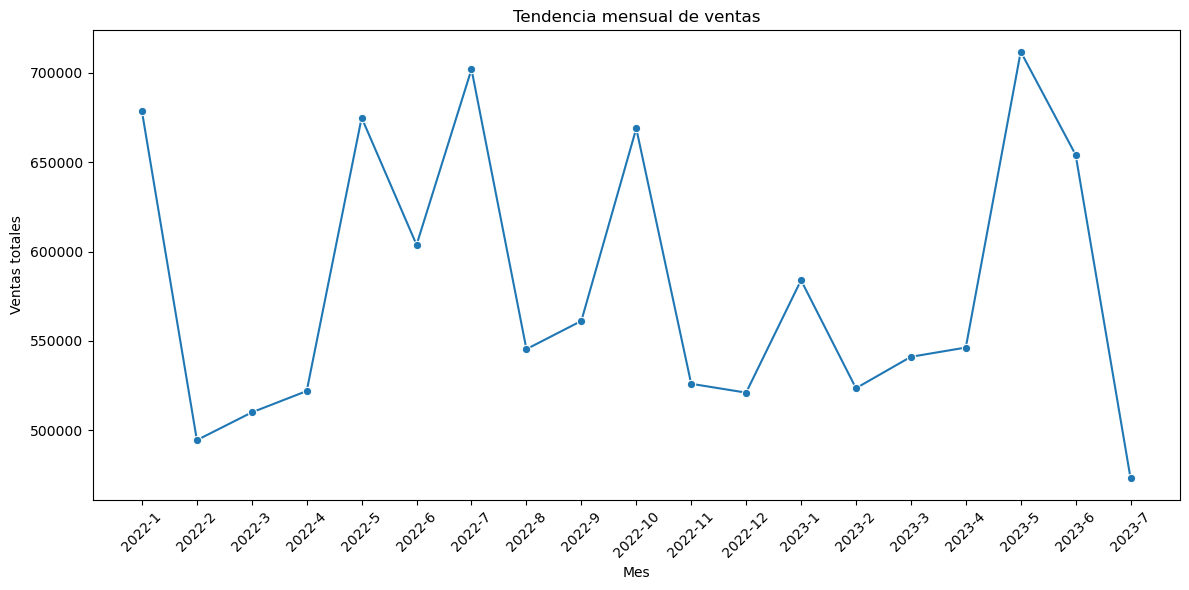

In [20]:
#Grafico de lineas: 
#a pesar de tener un historico en mayo del 2023, ha habido una caida abrupta para julio lo cual es atipico
#sin embargo en agosto y septiembre historicamente ha habido malas ventas.
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x="PERIODO", y="TOTAL_VALUE_SALES", marker="o")
plt.title("Tendencia mensual de ventas")
plt.xticks(rotation=45)
plt.ylabel("Ventas totales")
plt.xlabel("Mes")
plt.tight_layout()
plt.show()

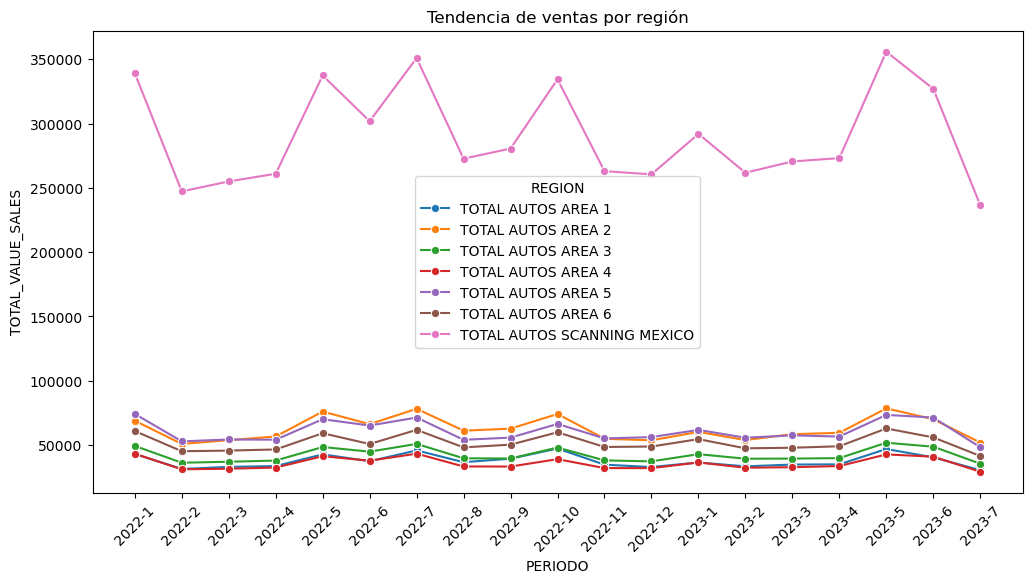

In [21]:
#ANALISIS DE PRODUCTO POR REGION
ventas_region = sales_calendar.groupby(["YEAR", "MONTH", "REGION"])["TOTAL_VALUE_SALES"].sum().reset_index()
ventas_region["PERIODO"] = ventas_region["YEAR"].astype(str) + "-" + ventas_region["MONTH"].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=ventas_region, x="PERIODO", y="TOTAL_VALUE_SALES", hue="REGION", marker="o")
plt.title("Tendencia de ventas por región")
plt.xticks(rotation=45)
plt.show()

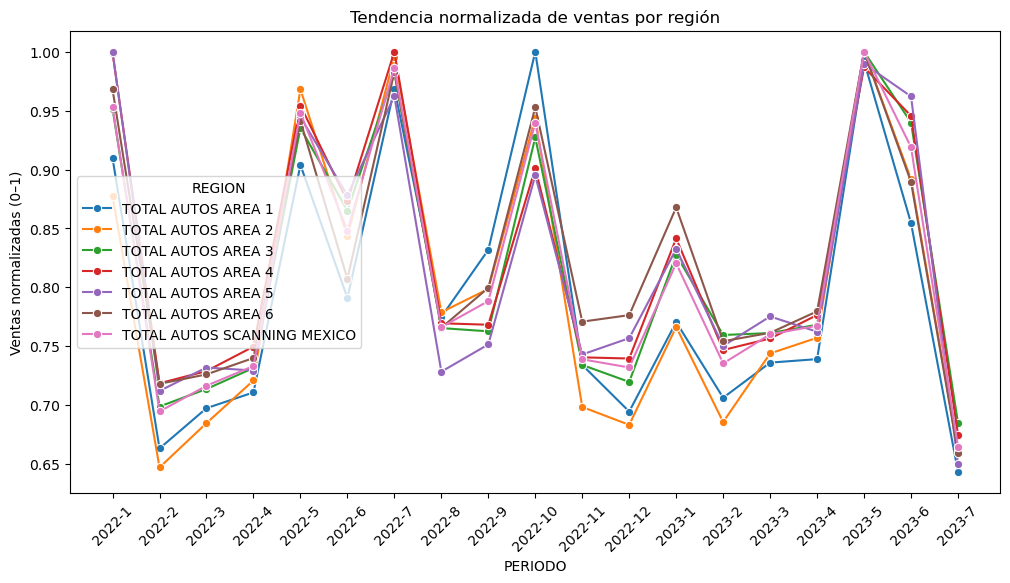

In [23]:
#Tendencia normalizada de ventas por region (lo mismo de arriba pero para evitar el impacto de datos grandes)
#En general Mexico muestra una alta tendencia, mientras que las demas regiones tienen comportamientos parecidos y estables,
#definitivamente la dominancia del mercado la sigue teniendo Mexico
ventas_region["NORMALIZADO"] = ventas_region.groupby("REGION")["TOTAL_VALUE_SALES"].transform(lambda x: x / x.max())

plt.figure(figsize=(12,6))
sns.lineplot(data=ventas_region, x="PERIODO", y="NORMALIZADO", hue="REGION", marker="o")
plt.title("Tendencia normalizada de ventas por región")
plt.xticks(rotation=45)
plt.ylabel("Ventas normalizadas (0–1)")
plt.show()

) missing from font(s) DejaVu Sans.\ipykernel_2416\1796519675.py:20: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


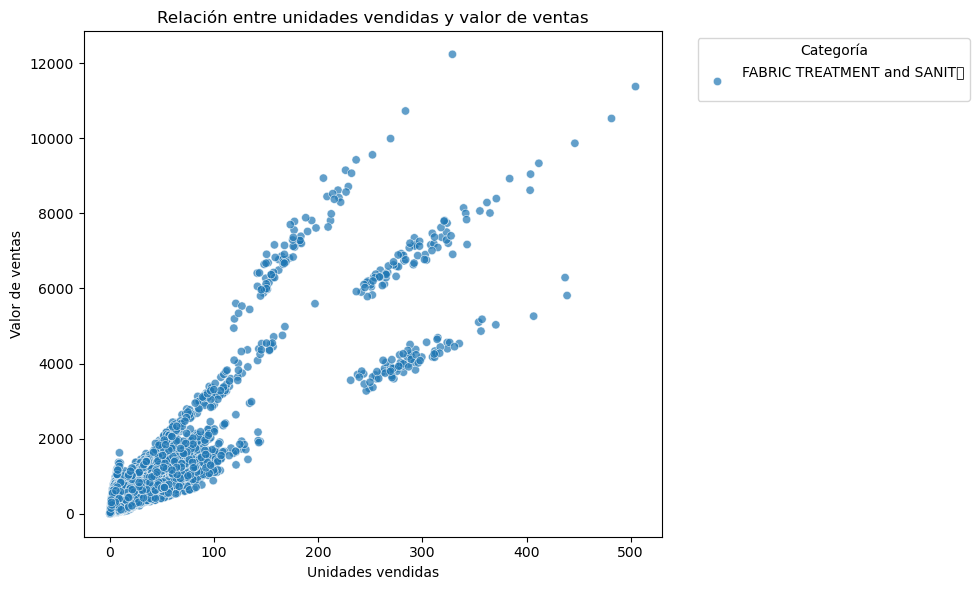

In [26]:
#Relacion de unidades vendidas y valores de ventas
#Las variables mas importantes son el total de ventas unitarias y su valor total por eso
#decidi comparar estas dos variables
#Aqui hay una buena correlacion de ventas por unidad, hay algunos outliers pero pudieran interpretarse como productos premium
#o algo por el estilo. El comportamiento de las ventas por unidad es bueno
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter básico: unidades vs. valor
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sales_products,
    x="TOTAL_UNIT_SALES",
    y="TOTAL_VALUE_SALES",
    hue="CATEGORY_y",  # ajusta si el nombre es distinto
    alpha=0.7
)
plt.title("Relación entre unidades vendidas y valor de ventas")
plt.xlabel("Unidades vendidas")
plt.ylabel("Valor de ventas")
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

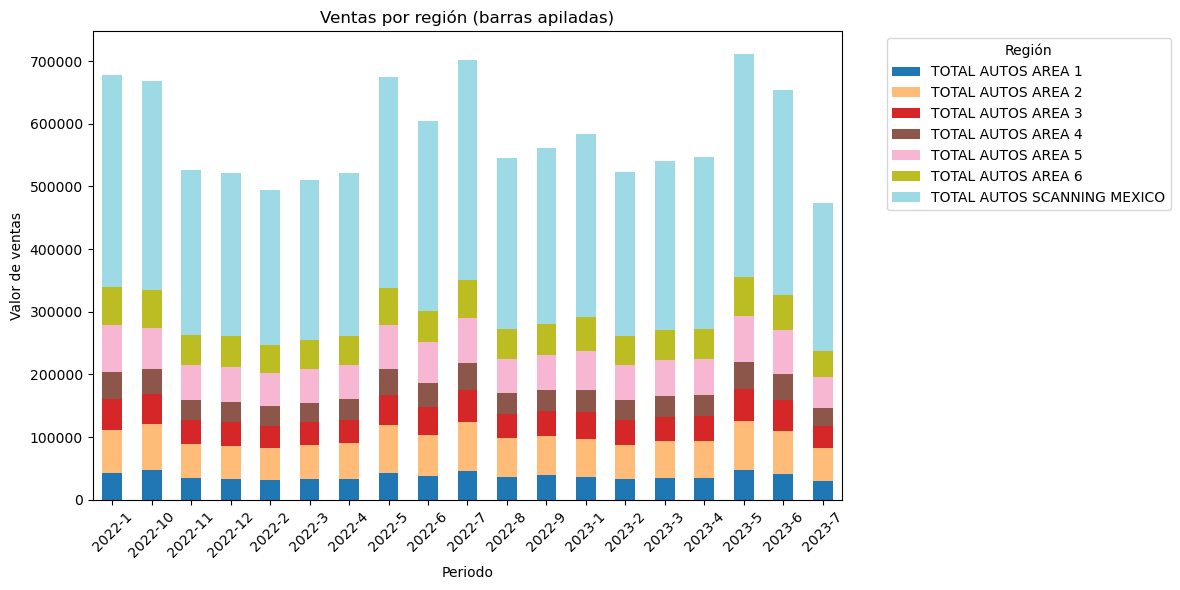

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

#Scanning Mexico es el gran referente porque es el que muestra alta dominancia con las barras azules. Tambien se 
#puede observar que hay lapsos de tiempo donde las ventas son mas bajas, pero son consistentes en dichos lapsos (como los
#meses de febrero, lo cual puede serventas bajas pero esperadas. Las demas areas son de pocas ventas, pero son constantes.

# Agrupar ventas por región y año-mes
ventas_region = sales_calendar.groupby(["YEAR", "MONTH", "REGION"])["TOTAL_VALUE_SALES"].sum().reset_index()
ventas_region["PERIODO"] = ventas_region["YEAR"].astype(str) + "-" + ventas_region["MONTH"].astype(str)

# Pivotear para apilar regiones
pivot_region = ventas_region.pivot(index="PERIODO", columns="REGION", values="TOTAL_VALUE_SALES").fillna(0)

# Gráfico de barras apiladas
pivot_region.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Ventas por región (barras apiladas)")
plt.ylabel("Valor de ventas")
plt.xlabel("Periodo")
plt.xticks(rotation=45)
plt.legend(title="Región", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\SURFACE\AppData\Local\Temp\ipykernel_2416\4178845126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


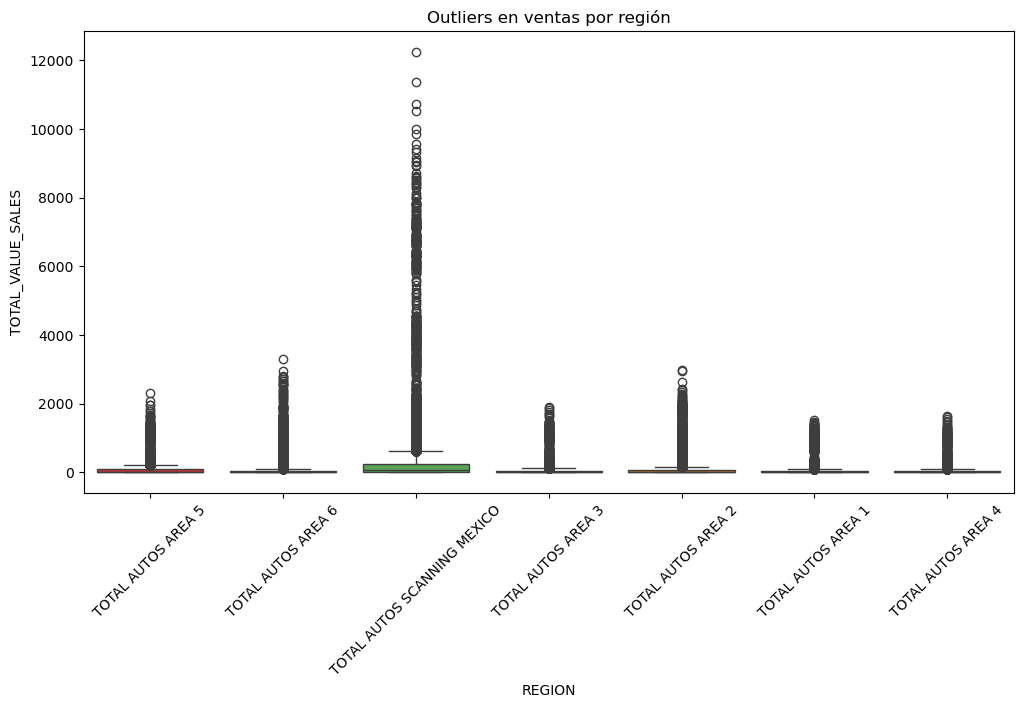

In [30]:
#Outliers por region. 
#Scanning Mexico muestra una alta dispersion, lo cual indica que tiene mucha variabilidad en las ventas, sin embargo tiene
#operaciones grandes, lo cual los outliers son esperados justo por esa variabilidad. En las demas areas y regiones, hay menos 
#outliers lo cual indica que las ventas son mas estables.

plt.figure(figsize=(12,6))
sns.boxplot(
    data=sales_products,
    x="REGION",
    y="TOTAL_VALUE_SALES",
    palette="Set1"
)
plt.title("Outliers en ventas por región")
plt.xticks(rotation=45)
plt.show()

In [1]:
## Insights y conclusiones

#Mexico es dominante en ventas, pero también muestra alta variabilidad y outliers (operaciones grandes y algo dispersas).
#Las regiones locales (Área 1–6) tienen ventas estables
#Las categorías presentan una distribución sesgada:.
#La relación entre unidades vendidas y valor de ventas tienen nuna correlacion posirtiva, pero con agrupamientosque indican posibles subcateogiras.
#Los outliers por región y producto revelan transacciones excepcionales que podrían analizarse más a fondo para detectar oportunidades o errores, en el ultimo por region puede notarse la dispersion de las ventasen Mexico, y la estabilidad en venta en otras regiones
#Las tendencias normalizadas por región permiten comparar comportamientos internos, revelando picos y caídas que no eran visibles en los gráficos absolutos.


In [6]:
import os
os.makedirs("outputs", exist_ok=True)

In [7]:
plt.savefig("outputs/01_hist_categoria.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Histograma por categoría
plt.figure(figsize=(10,6))
sns.histplot(data=sales_products, x="TOTAL_VALUE_SALES", bins=30, kde=True)
plt.title("Distribución de ventas por categoría (Histograma)")
plt.xlabel("Valor de ventas")
plt.ylabel("Frecuencia")
plt.savefig("outputs/01_hist_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Boxplot por categoría
plt.figure(figsize=(10,6))
sns.boxplot(data=sales_products, x="CATEGORY_y", y="TOTAL_VALUE_SALES", palette="Set2")
plt.title("Outliers en ventas por categoría")
plt.xticks(rotation=45)
plt.savefig("outputs/02_box_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Boxplot por región
plt.figure(figsize=(10,6))
sns.boxplot(data=sales_products, x="REGION", y="TOTAL_VALUE_SALES", palette="Set1")
plt.title("Outliers en ventas por región")
plt.xticks(rotation=45)
plt.savefig("outputs/03_box_region.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Gráfico de líneas por región
plt.figure(figsize=(12,6))
sns.lineplot(data=ventas_region, x="PERIODO", y="TOTAL_VALUE_SALES", hue="REGION", marker="o")
plt.title("Tendencia de ventas por región")
plt.xticks(rotation=45)
plt.savefig("outputs/04_linea_region.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Gráfico de líneas normalizado por región
plt.figure(figsize=(12,6))
sns.lineplot(data=ventas_region, x="PERIODO", y="NORMALIZADO", hue="REGION", marker="o")
plt.title("Tendencia normalizada de ventas por región")
plt.xticks(rotation=45)
plt.savefig("outputs/05_linea_region_normalizado.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Barras apiladas por región
pivot_region.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Ventas por región (barras apiladas)")
plt.ylabel("Valor de ventas")
plt.xlabel("Periodo")
plt.xticks(rotation=45)
plt.legend(title="Región", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("outputs/06_barras_apiladas.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Scatter plot (unidades vs valor de ventas)
plt.figure(figsize=(10,6))
sns.scatterplot(data=sales_products, x="TOTAL_UNIT_SALES", y="TOTAL_VALUE_SALES", hue="CATEGORY_y", alpha=0.7)
plt.title("Relación entre unidades vendidas y valor de ventas")
plt.xlabel("Unidades vendidas")
plt.ylabel("Valor de ventas")
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("outputs/07_scatter_unidades_valor.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Boxplot por producto (Top 10 productos)
top_items = sales_products.groupby("ITEM_CODE")["TOTAL_VALUE_SALES"].sum().nlargest(10).index
filtered = sales_products[sales_products["ITEM_CODE"].isin(top_items)]
plt.figure(figsize=(10,6))
sns.boxplot(data=filtered, x="ITEM_CODE", y="TOTAL_VALUE_SALES", palette="Set3")
plt.title("Outliers en ventas (Top 10 productos)")
plt.xticks(rotation=45)
plt.savefig("outputs/08_box_producto.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'sales_products' is not defined

<Figure size 1000x600 with 0 Axes>